In [1]:
from deeplatent import Corpus, GTM, generate_documents
from sklearn.feature_extraction.text import CountVectorizer

df_theta, df, topic_words, true_lambda, true_label_coeffs = generate_documents(
    num_docs=10000,
    num_topics=3,
    vocab_size=500,
    min_words=100,
    max_words=100,
    num_covs=2,
    num_languages=1,
    doc_topic_prior="logistic_normal",
    label_type="regression",
    random_seed=1234
)

In [2]:
# ---- 1. Fit vectorizer on training set ----
vectorizer = CountVectorizer()  
vectorizer.fit(df["doc_clean_0"])

# ---- 2. Define modalities using this vectorizer ----
modalities = {
    "text": {
        "column": "doc_clean_0",
        "views": {
            "bow": {
                "type": "bow",
                "vectorizer": vectorizer
            }
        }
    }
}

# ---- 3. Create GTMCorpus datasets ----
train_dataset = Corpus(
    df,
    modalities=modalities,
    labels="~label-1",
    prevalence="~cov_1 + cov_2"
)

In [10]:
# Train the model

encoder_args = {
    "text_bow": {
        "hidden_dims": [128,64],
        "activation": "relu",
        "bias": True,
        "dropout": 0.0
    }
}

decoder_args = {
    "text_bow": {
        "hidden_dims": [],
        "activation": "relu",
        "bias": True,
        "dropout": 0.0
    }
}

predictor_args = {
    "text_bow": {
        "hidden_dims": [],
        "activation": "relu",
        "bias": False,
        "dropout": 0.0
    }
}

optim_args = {
    "main": {
        "lr": 1e-3, 
        "weight_decay": 0.0  # L2 penalty for main parameters 
    }
}

tm = GTM(
    train_dataset, 
    ae_type="vae",
    update_prior=True,
    optim_args=optim_args,
    encoder_args=encoder_args,
    decoder_args=decoder_args,
    predictor_args=predictor_args,
    n_topics=3,
    batch_size=100,
    predictor_type='regressor', 
    w_pred_loss=1,
    w_prior=0.01,
    print_every_n_steps=1000,
    num_steps=10000
)

Step   1000	Mean Training Loss:5.2624736
Rec Loss:5.2398500
Divergence Loss:0.0135115
Pred Loss:0.0091120

Step   2000	Mean Training Loss:5.1193323
Rec Loss:5.0997076
Divergence Loss:0.0144983
Pred Loss:0.0051266

Step   3000	Mean Training Loss:5.1170645
Rec Loss:5.0951853
Divergence Loss:0.0153643
Pred Loss:0.0065151

Step   4000	Mean Training Loss:5.1232514
Rec Loss:5.1011491
Divergence Loss:0.0150571
Pred Loss:0.0070451

Step   5000	Mean Training Loss:5.0983424
Rec Loss:5.0754523
Divergence Loss:0.0161165
Pred Loss:0.0067733

Step   6000	Mean Training Loss:5.0817442
Rec Loss:5.0593634
Divergence Loss:0.0180497
Pred Loss:0.0043313

Step   7000	Mean Training Loss:5.0491543
Rec Loss:5.0172033
Divergence Loss:0.0266358
Pred Loss:0.0053153

Step   8000	Mean Training Loss:5.0289230
Rec Loss:4.9963098
Divergence Loss:0.0263663
Pred Loss:0.0062468

Step   9000	Mean Training Loss:5.0660257
Rec Loss:5.0324569
Divergence Loss:0.0287530
Pred Loss:0.0048154

Step  10000	Mean Training Loss:5.0004

Topic alignment permutation: [2 0 1]
Correlation matrix:
 [[-0.2975477  -0.54691767  0.97328788]
 [ 0.98550362 -0.56155107 -0.37885935]
 [-0.59518236  0.97805261 -0.53712303]]


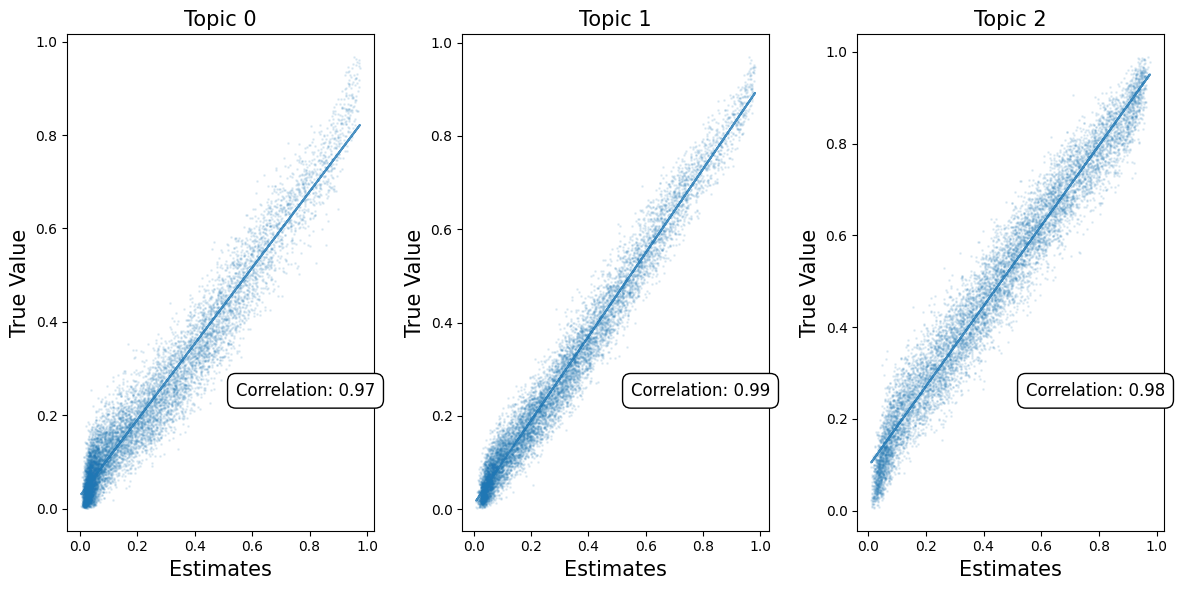

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linear_sum_assignment

# Step 1 — get estimated doc-topic matrix
full_dataset = Corpus(
    df,
    modalities=modalities,
    labels="~label-1",
    prevalence="~cov_1 + cov_2"
)
estimated_doc_topics = tm.get_doc_topic_distribution(full_dataset, num_samples=30)

# Step 2 — align topics using Hungarian algorithm
K = estimated_doc_topics.shape[1]
corr_matrix = np.zeros((K, K))

for i in range(K):
    for j in range(K):
        corr_matrix[i, j] = np.corrcoef(
            estimated_doc_topics[:, i],
            df_theta[f"Topic{j}"]
        )[0, 1]

# maximize absolute correlation
row_ind, col_ind = linear_sum_assignment(-np.abs(corr_matrix))

# reorder df_theta based on optimal assignment
df_theta_aligned = df_theta[[f"Topic{j}" for j in col_ind]]
df_theta_aligned.columns = [f"Topic{i}" for i in range(K)]

print("Topic alignment permutation:", col_ind)
print("Correlation matrix:\n", corr_matrix)

# Step 3 — plotting (same as your code)
fig, axs = plt.subplots(1, 3, figsize=(12, 6))

for i in range(3):
    x = estimated_doc_topics[:, i]
    y = df_theta_aligned[f"Topic{i}"]
    
    axs[i].scatter(x, y, s=1, alpha=0.1)
    
    coefficients = np.polyfit(x, y, 1)
    fit = np.poly1d(coefficients)
    axs[i].plot(x, fit(x), alpha=0.8)
    
    axs[i].set_xlabel('Estimates', fontsize=15)
    axs[i].set_ylabel('True Value', fontsize=15)
    axs[i].set_title(f'Topic {i}', fontsize=15)

    corr_coeff = np.corrcoef(x, y)[0, 1]
    axs[i].annotate(
        f'Correlation: {corr_coeff:.2f}',
        xy=(0.55, 0.3), xycoords='axes fraction',
        fontsize=12, verticalalignment='top', horizontalalignment='left',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
    )

plt.tight_layout()
plt.show()


In [12]:
print("True label_coeffs:\n", true_label_coeffs)

print('Estimated weights:')
print(tm.predictor.neural_net["pred_0"].weight.detach().cpu())

True label_coeffs:
 [-0.814588    0.41718749  0.45773178]
Estimated weights:
tensor([[ 0.1069, -0.9602,  0.1486]])


In [13]:
tm.get_predictions(full_dataset, to_numpy=False, num_samples=30)[0:10]

tensor([[ 0.2474],
        [ 0.2497],
        [ 0.1919],
        [-0.3518],
        [ 0.3361],
        [ 0.1634],
        [ 0.1034],
        [-0.3022],
        [ 0.3375],
        [ 0.3595]], device='cuda:0')

In [14]:
print(df['label'].iloc[0:10])

0    0.299451
1    0.344011
2    0.289740
3   -0.392198
4    0.310445
5    0.195428
6    0.127682
7   -0.301513
8    0.335144
9    0.352473
Name: label, dtype: float64
